
First 5 Rows:

   CustomerId  CreditScore Geography  Gender  Age  Tenure    Balance  \
0      100000          452    France    Male   61       3  155159.24   
1      100001          785   Germany  Female   23       1  190631.42   
2      100002          620    France  Female   45       1  183889.55   
3      100003          456     Spain  Female   62       3  203605.89   
4      100004          421   Germany    Male   43       5    8046.10   

   NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0              1          0               0         49694.93       1  
1              4          1               1         27337.13       0  
2              1          0               1         88131.00       1  
3              1          0               1         76732.83       1  
4              3          0               1        112128.37       0  

Dataset Shape:
(5000, 12)


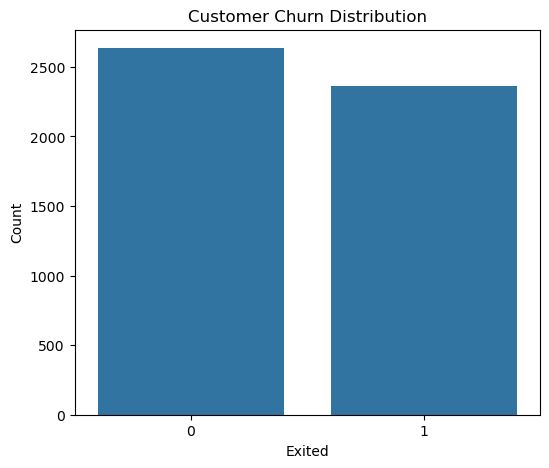

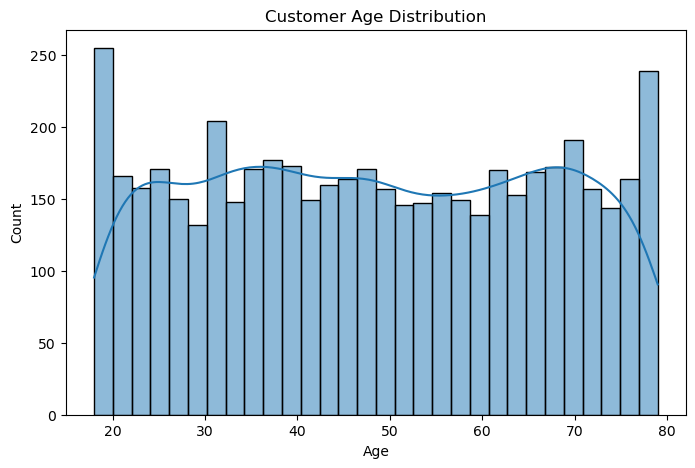

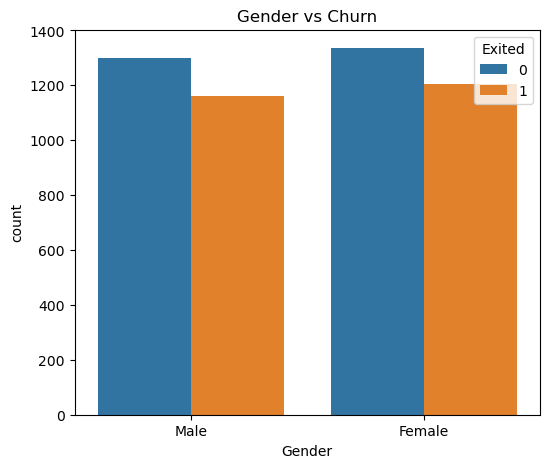

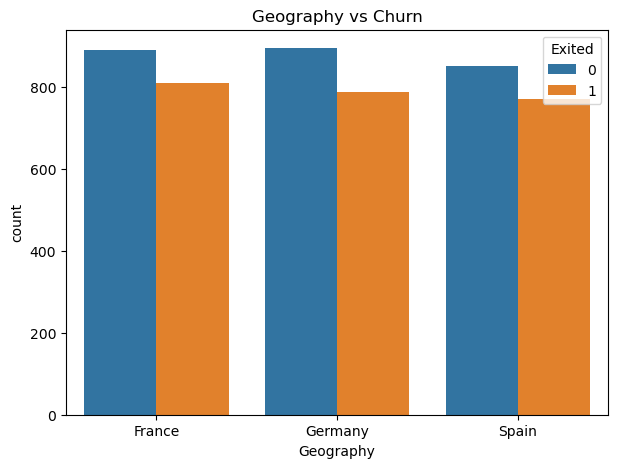

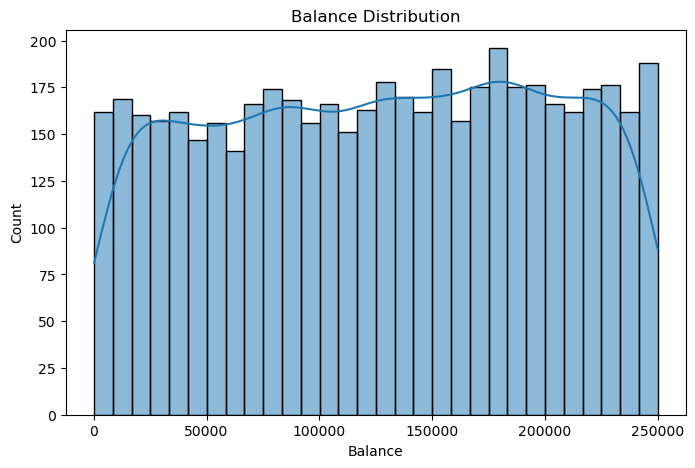

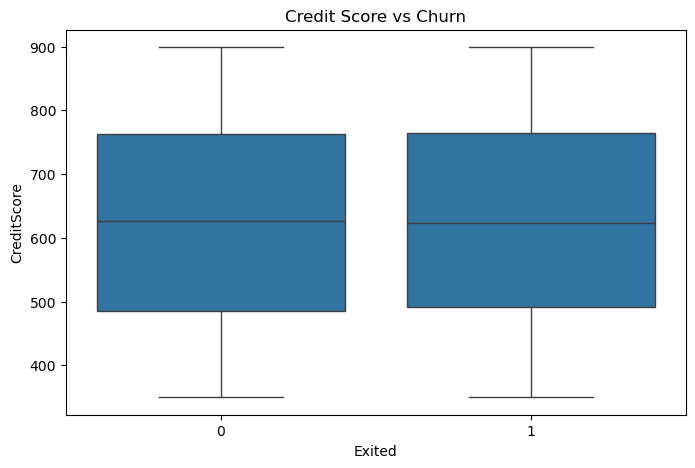

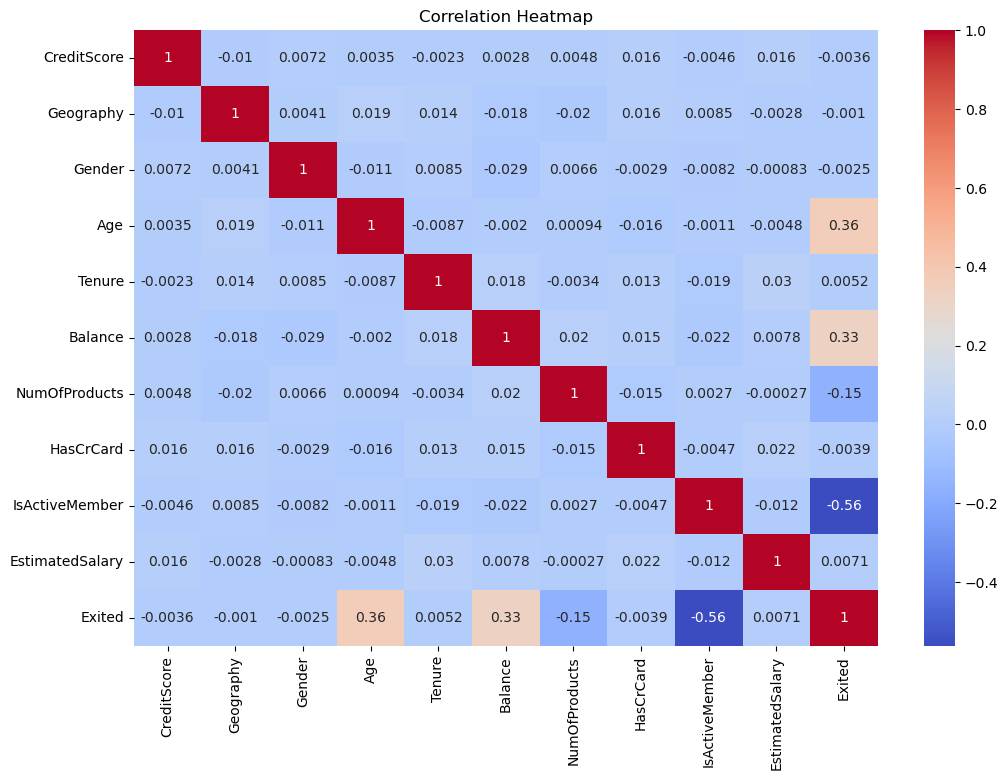


MODEL PERFORMANCE

Accuracy Score:
0.952

ROC AUC Score:
0.991041878116588

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       527
           1       0.95      0.95      0.95       473

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



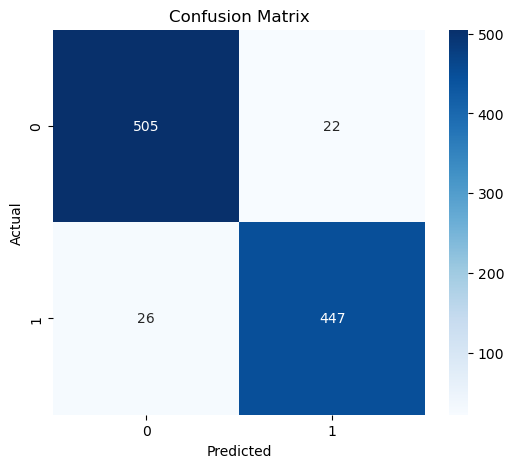

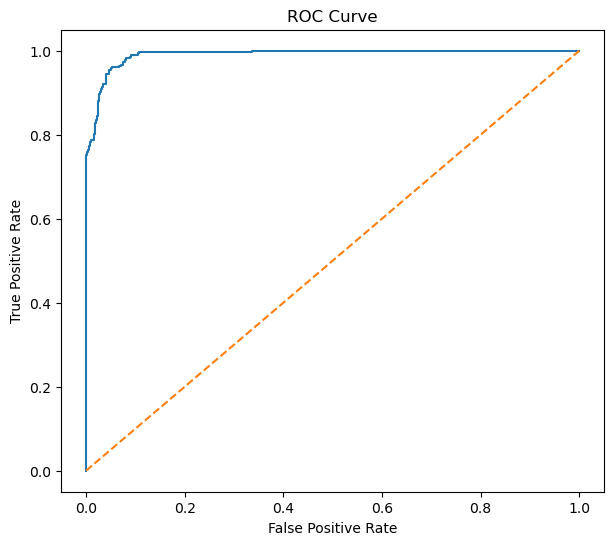


Top Important Features:

           Feature  Importance
8   IsActiveMember    0.423782
3              Age    0.247291
5          Balance    0.228526
6    NumOfProducts    0.063429
9  EstimatedSalary    0.013874
0      CreditScore    0.012996
4           Tenure    0.005144
1        Geography    0.002144
7        HasCrCard    0.001647
2           Gender    0.001167


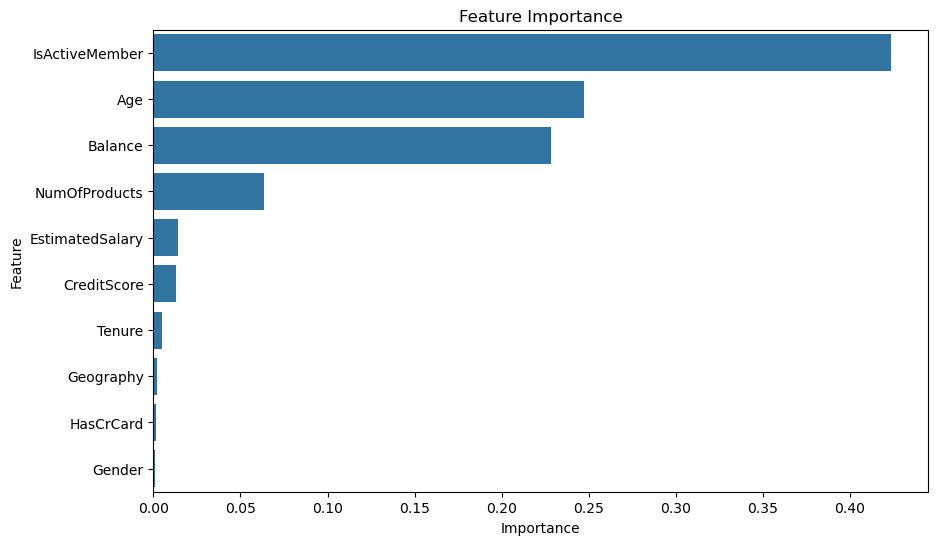

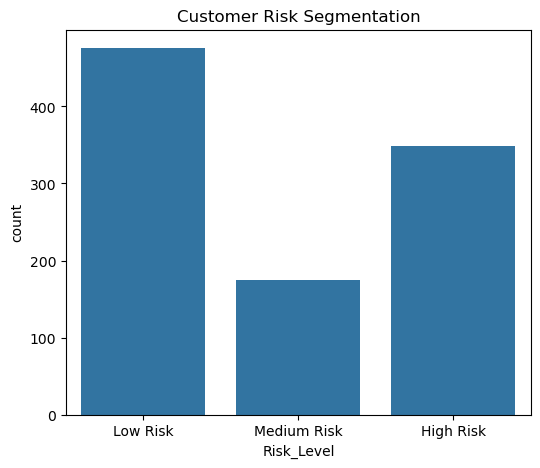


Total High Risk Customers:
349

Estimated Revenue Saved: ₹ 5,235,000

Predictions CSV Saved Successfully!


In [11]:
# ============================================
# RetentionIQ for Banking
# AI-Powered Banking Churn Prediction System
# WITH GRAPHICAL VISUALIZATIONS
# ============================================

# Install Required Libraries
# pip install pandas numpy scikit-learn matplotlib seaborn

# ============================================
# IMPORT LIBRARIES
# ============================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier

# ============================================
# LOAD DATASET FROM LOCAL PATH
# ============================================

dataset_path = r"D:\hackathon\bank_churn.csv"

df = pd.read_csv(dataset_path)

# ============================================
# BASIC DATA INFO
# ============================================

print("\nFirst 5 Rows:\n")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# ============================================
# DATA VISUALIZATION
# ============================================

# Churn Distribution
plt.figure(figsize=(6,5))

sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution")

plt.xlabel("Exited")

plt.ylabel("Count")

plt.show()

# ============================================

# Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Customer Age Distribution")

plt.show()

# ============================================

# Gender vs Churn
plt.figure(figsize=(6,5))

sns.countplot(
    x='Gender',
    hue='Exited',
    data=df
)

plt.title("Gender vs Churn")

plt.show()

# ============================================

# Geography vs Churn
plt.figure(figsize=(7,5))

sns.countplot(
    x='Geography',
    hue='Exited',
    data=df
)

plt.title("Geography vs Churn")

plt.show()

# ============================================

# Balance Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Balance'], bins=30, kde=True)

plt.title("Balance Distribution")

plt.show()

# ============================================

# Credit Score vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='CreditScore',
    data=df
)

plt.title("Credit Score vs Churn")

plt.show()

# ============================================
# DATA CLEANING
# ============================================

drop_cols = ['RowNumber', 'CustomerId', 'Surname']

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# ============================================
# ENCODE CATEGORICAL VARIABLES
# ============================================

le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# ============================================
# CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# ============================================
# FEATURES & TARGET
# ============================================

X = df.drop("Exited", axis=1)

y = df["Exited"]

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================
# MODEL TRAINING
# ============================================

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

# ============================================
# PREDICTIONS
# ============================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

# ============================================
# MODEL EVALUATION
# ============================================

print("\n================================")
print("MODEL PERFORMANCE")
print("================================")

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ============================================
# ROC CURVE
# ============================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

# ============================================
# FEATURE IMPORTANCE
# ============================================

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': model.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features:\n")
print(importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

# ============================================
# CHURN RISK SEGMENTATION
# ============================================

risk_df = X_test.copy()

risk_df['Churn_Probability'] = y_prob

# ============================================
# RISK CATEGORY
# ============================================

def risk_category(prob):

    if prob < 0.30:
        return "Low Risk"

    elif prob < 0.70:
        return "Medium Risk"

    else:
        return "High Risk"

risk_df['Risk_Level'] = risk_df[
    'Churn_Probability'
].apply(risk_category)

# ============================================
# RISK DISTRIBUTION GRAPH
# ============================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='Risk_Level',
    data=risk_df
)

plt.title("Customer Risk Segmentation")

plt.show()

# ============================================
# BUSINESS INSIGHTS
# ============================================

high_risk = risk_df[
    risk_df['Risk_Level'] == 'High Risk'
]

print("\nTotal High Risk Customers:")
print(len(high_risk))

estimated_loss_per_customer = 50000

estimated_revenue_saved = (
    len(high_risk) *
    estimated_loss_per_customer *
    0.30
)

print(
    f"\nEstimated Revenue Saved: ₹ {estimated_revenue_saved:,.0f}"
)

# ============================================
# SAVE OUTPUT
# ============================================

risk_df.to_csv(
    "bank_churn_predictions.csv",
    index=False
)

print("\nPredictions CSV Saved Successfully!")

# ============================================
# END OF PROJECT
# ============================================
